Average Price: 94.974103927395
Maximum Price: 105.38602017570291
Minimum Price: 86.97331388340096


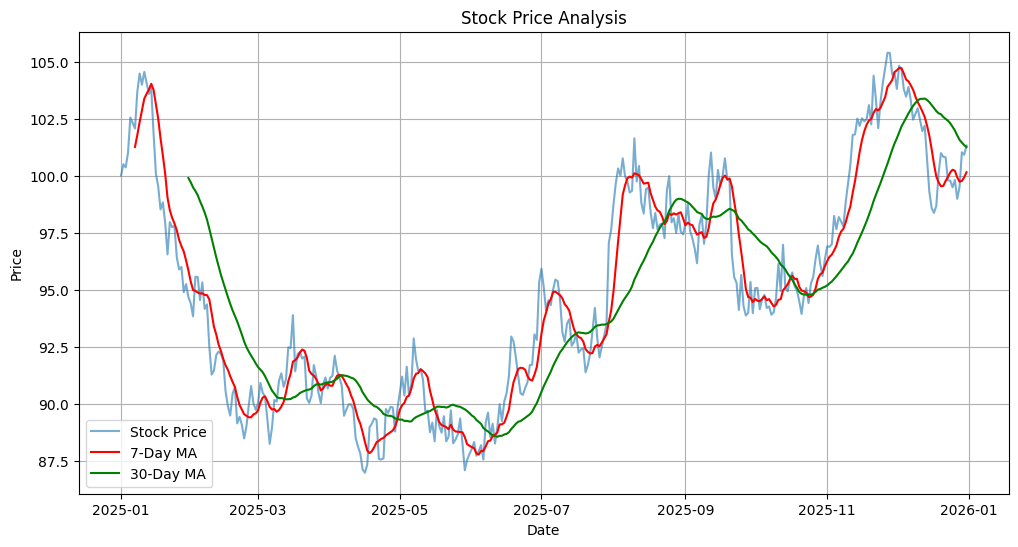

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Generate date range
dates = pd.date_range(start='2025-01-01', periods=365, freq='D')

# Step 2: Simulate stock prices using random walk
np.random.seed(42)
price = 100  # initial stock price
prices = [price]

for i in range(1, 365):
    change = np.random.normal(0, 1)  # daily return
    price = prices[-1] * (1 + change/100)
    prices.append(price)

# Step 3: Create DataFrame
df = pd.DataFrame({'Date': dates, 'Stock Price': prices})
df.set_index('Date', inplace=True)

# Step 4: Basic metrics
print("Average Price:", np.mean(df['Stock Price']))
print("Maximum Price:", np.max(df['Stock Price']))
print("Minimum Price:", np.min(df['Stock Price']))

# Daily returns
df['Daily Return'] = df['Stock Price'].pct_change()

# Step 5: Moving averages
df['MA_7'] = df['Stock Price'].rolling(window=7).mean()
df['MA_30'] = df['Stock Price'].rolling(window=30).mean()

# Step 6: Visualization
plt.figure(figsize=(12,6))
plt.plot(df['Stock Price'], label='Stock Price', alpha=0.6)
plt.plot(df['MA_7'], label='7-Day MA', color='red')
plt.plot(df['MA_30'], label='30-Day MA', color='green')

plt.title("Stock Price Analysis")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()